# 03 — Regime-shift transfer (H3)

Inputs: `results/metrics/transfer/run_metrics.csv` (2 agents × 4 phases × 30 seeds = 240 runs).

H3: Q-tables learned in a calm regime degrade when transferred to a stressed regime; native re-training closes the gap. We measure the **transfer penalty** = mean(native) − mean(transferred) per agent and direction.

Phases:
- `train_calm`: native training in low-vol, 0% toxicity.
- `train_stressed`: native training in high-vol, 30% toxicity.
- `transferred_calm_to_stressed`: load calm-trained policy, evaluate (frozen) in stressed regime.
- `transferred_stressed_to_calm`: reverse.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "pyproject.toml").exists() or (cand / "src/lob_market_making_agents").exists():
            return cand
    return here

REPO_ROOT = _find_repo_root()
src_path = str(REPO_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from lob_market_making_agents.analysis.plots import (
    agent_palette, bootstrap_ci, save_figure, transfer_phase,
)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 144, "axes.grid": True, "grid.alpha": 0.3})

TRANSFER_CSV = REPO_ROOT / "results/metrics/transfer/run_metrics.csv"
FIG_DIR = REPO_ROOT / "results/figures/transfer"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv(TRANSFER_CSV)
df["phase"] = df.config_name.map(transfer_phase)
print("rows:", len(df), "  agents:", sorted(df.agent.unique()))
print("phases:", sorted(df.phase.unique()))
assert len(df) == 240

rows: 240   agents: ['C', 'C_PLUS']
phases: ['train_calm', 'train_stressed', 'transferred_calm_to_stressed', 'transferred_stressed_to_calm']


## Pair native vs transferred per direction

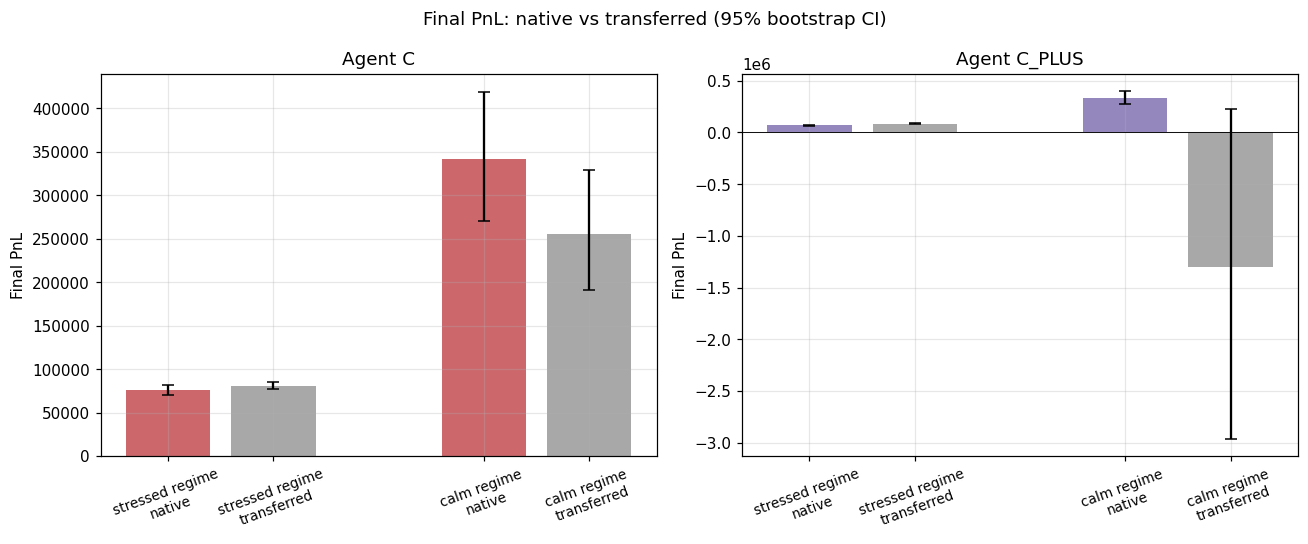

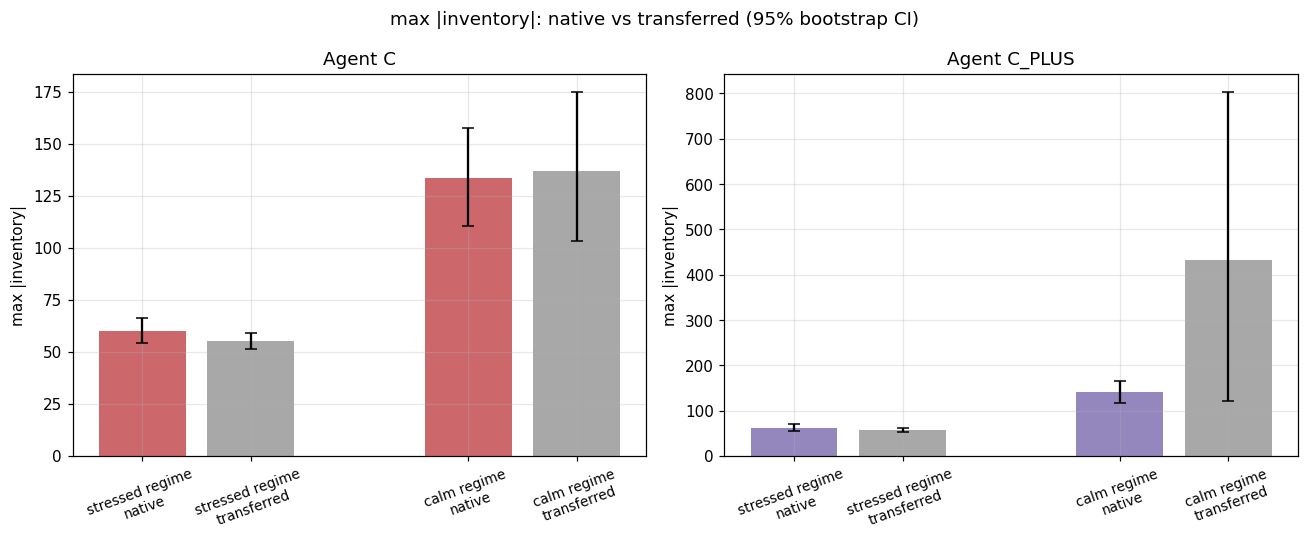

In [3]:
PAIRS = [
    ("stressed regime", "train_stressed", "transferred_calm_to_stressed"),
    ("calm regime", "train_calm", "transferred_stressed_to_calm"),
]


def bar_grid(metric: str, ylabel: str, fname: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
    palette = agent_palette()
    for ax, agent in zip(axes, ("C", "C_PLUS")):
        x_positions = []
        labels = []
        means, los, his, colors = [], [], [], []
        for i, (regime, native, transferred) in enumerate(PAIRS):
            for j, (kind, phase) in enumerate([("native", native), ("transferred", transferred)]):
                cell = df[(df.agent == agent) & (df.phase == phase)][metric].values
                m, lo, hi = bootstrap_ci(cell, seed=hash((agent, phase, metric)) & 0xFFFF)
                pos = i * 3 + j
                x_positions.append(pos)
                labels.append(f"{regime}\n{kind}")
                means.append(m); los.append(lo); his.append(hi)
                colors.append(palette[agent] if kind == "native" else "#999999")
        err = np.array([[m - lo for m, lo in zip(means, los)], [hi - m for m, hi in zip(means, his)]])
        ax.bar(x_positions, means, yerr=err, color=colors, alpha=0.85, capsize=4)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(labels, rotation=20, fontsize=9)
        ax.axhline(0, color="black", linewidth=0.6)
        ax.set_title(f"Agent {agent}")
        ax.set_ylabel(ylabel)
    fig.suptitle(f"{ylabel}: native vs transferred (95% bootstrap CI)", fontsize=12)
    save_figure(fig, FIG_DIR / fname)
    plt.show()


bar_grid("final_pnl", "Final PnL", "pnl_bars.png")
bar_grid("inventory_max_abs", "max |inventory|", "inventory_bars.png")

## Transfer penalty table

In [4]:
records = []
for agent in ("C", "C_PLUS"):
    for regime, native, transferred in PAIRS:
        nat = df[(df.agent == agent) & (df.phase == native)]
        trf = df[(df.agent == agent) & (df.phase == transferred)]
        records.append({
            "agent": agent, "regime": regime,
            "native_pnl_mean": nat.final_pnl.mean(),
            "transferred_pnl_mean": trf.final_pnl.mean(),
            "transfer_penalty_pnl": nat.final_pnl.mean() - trf.final_pnl.mean(),
            "native_inv_mean": nat.inventory_max_abs.mean(),
            "transferred_inv_mean": trf.inventory_max_abs.mean(),
            "transfer_penalty_inv": trf.inventory_max_abs.mean() - nat.inventory_max_abs.mean(),
        })
penalty = pd.DataFrame.from_records(records)
out = REPO_ROOT / "results/metrics/transfer/transfer_penalty.csv"
penalty.to_csv(out, index=False)
print("wrote", out)
penalty.round(3)

wrote /Users/lewis/Documents/Work/LOB Market Maker Agents/LOB-Market-Making-Agents/results/metrics/transfer/transfer_penalty.csv


,agent,regime,native_pnl_mean,transferred_pnl_mean,transfer_penalty_pnl,native_inv_mean,transferred_inv_mean,transfer_penalty_inv
0,C,stressed regime,75710.504,80820.088,-5109.584,59.933,54.967,-4.967
1,C,calm regime,341296.737,255810.739,85485.998,133.400,136.800,3.400
2,C_PLUS,stressed regime,68685.320,81228.447,-12543.127,61.933,56.567,-5.367
3,C_PLUS,calm regime,333907.742,-1303974.959,1637882.701,141.067,431.667,290.600


## Paired Wilcoxon signed-rank tests

Native and transferred runs share the seed list by construction, so the natural unit of inference is the **per-seed difference**, not the unpaired marginal. We compute `Δpnl = native − transferred` and `Δinv = transferred − native` per `(agent, seed)` for each direction, then run a paired Wilcoxon signed-rank test on each metric. Wilcoxon (rather than a paired t-test) is used because the per-seed PnL differences under stressed flow are heavy-tailed.

Output: `results/metrics/transfer/wilcoxon_tests.csv` with columns `agent, regime, metric, n_pairs, w_stat, p_value, median_diff`.

In [5]:
from scipy.stats import wilcoxon

wilcoxon_records = []
for agent in ("C", "C_PLUS"):
    for regime, native_phase, transferred_phase in PAIRS:
        nat = (df[(df.agent == agent) & (df.phase == native_phase)]
               [["seed", "final_pnl", "inventory_max_abs"]]
               .rename(columns={"final_pnl": "pnl_native",
                                "inventory_max_abs": "inv_native"}))
        trf = (df[(df.agent == agent) & (df.phase == transferred_phase)]
               [["seed", "final_pnl", "inventory_max_abs"]]
               .rename(columns={"final_pnl": "pnl_transferred",
                                "inventory_max_abs": "inv_transferred"}))
        paired = nat.merge(trf, on="seed", how="inner")
        if paired.empty:
            continue

        # Sign convention matches transfer_penalty.csv: positive Δpnl means the transfer hurt;
        # positive Δinv means the frozen policy let inventory drift further.
        d_pnl = (paired.pnl_native - paired.pnl_transferred).values
        d_inv = (paired.inv_transferred - paired.inv_native).values

        for metric, diffs in (("final_pnl", d_pnl), ("inventory_max_abs", d_inv)):
            # zero_method='wilcox' drops zero-difference pairs (scipy default behaviour
            # since 1.9; named explicitly so the test is reproducible across versions).
            res = wilcoxon(diffs, zero_method="wilcox", alternative="two-sided")
            wilcoxon_records.append({
                "agent": agent,
                "regime": regime,
                "metric": metric,
                "n_pairs": int(len(diffs)),
                "w_stat": float(res.statistic),
                "p_value": float(res.pvalue),
                "median_diff": float(np.median(diffs)),
            })

wilcoxon_df = pd.DataFrame.from_records(wilcoxon_records)
out = REPO_ROOT / "results/metrics/transfer/wilcoxon_tests.csv"
wilcoxon_df.to_csv(out, index=False)
print("wrote", out)
wilcoxon_df.round(4)

wrote /Users/lewis/Documents/Work/LOB Market Maker Agents/LOB-Market-Making-Agents/results/metrics/transfer/wilcoxon_tests.csv


,agent,regime,metric,n_pairs,w_stat,p_value,median_diff
0,C,stressed regime,final_pnl,30,132.0,0.0384,-3801.0089
1,C,stressed regime,inventory_max_abs,30,161.0,0.2215,-2.5000
2,C,calm regime,final_pnl,30,152.0,0.1004,47678.7500
3,C,calm regime,inventory_max_abs,30,228.0,0.9263,-14.0000
4,C_PLUS,stressed regime,final_pnl,30,66.0,0.0003,-13723.2571
5,C_PLUS,stressed regime,inventory_max_abs,30,167.0,0.1774,-2.0000
6,C_PLUS,calm regime,final_pnl,30,82.0,0.0013,134989.7302
7,C_PLUS,calm regime,inventory_max_abs,30,228.0,0.9263,-17.5000


## Notes for the report
- Inventory penalty is reported with sign convention `transferred − native` so a positive number means the frozen policy let inventory drift further than a natively-trained one.
- The PnL penalty uses `native − transferred` so positive numbers indicate the transfer hurt expected revenue.